<a href="https://colab.research.google.com/github/roywe/book_generator_tom/blob/main/TOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# colab installs
!pip install deep_translator
!wget -O NotoSansSymbols2-Regular.ttf https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSymbols2/NotoSansSymbols2-Regular.ttf
!pip install ezdxf
!pip install opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.4 MB/s eta 0:00:00
--2026-05-27 14:55:54--  https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSymbols2/NotoSansSymbols2-Regular.ttf
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSansSymbols2/NotoSansSymbols2-Regular.ttf [following]
--2026-05-27 14:55:54--  https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSansSymbols2/NotoSansSymbols2-Regular.ttf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSansSymbols2/NotoSansSymbols2-Regular.ttf [following]
--2026-05-27 14:55:54--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSansSymbols2

In [2]:
# Imports
%matplotlib inline
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers import AutoencoderKL, UNet2DConditionModel, AutoPipelineForText2Image
from diffusers import LMSDiscreteScheduler
from deep_translator import GoogleTranslator
import re
import cv2
import numpy as np
import ezdxf
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# font_path = "/content/NotoSansSymbols2-Regular.ttf"
font_path = "NotoSansSymbols2-Regular.ttf"

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans Symbols2'

# device to be used
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Using device", device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device cuda:0


In [3]:
def hebrew_translator(user_prompt):
    """
    function for testing whether user's input is in Hebrew or in English - if it's
    in Hebrew then it will translate it to English
    :param user_prompt:
    :return:
    """
    contains_hebrew = re.search(r"[\u0590-\u05FF]", user_prompt) is not None
    if contains_hebrew:
        return GoogleTranslator(source='auto', target='en').translate(user_prompt)
    else:
        prompt_en = user_prompt

    return prompt_en

In [4]:
def add_nikud(text):
    """
    מוסיפה סימנים לוגיים (יוניקוד) לפי בחירת המשתמש:
    ב כ פ – דגש
    ו – חולם / שורוק / רגיל
    י – עם חיריק / בלי
    ש – s או sh
    """

    result = ""

    for ch in text:

        # ב כ פ – דגש
        if ch in ('ב', 'כ', 'פ'):
            ans = input(f"האם האות '{ch}' היא עם דגש? (כן/לא) ").strip().lower()
            result += ch
            if ans == 'כן':
                result += DAGESH

        # ו – חולם / שורוק / רגיל
        elif ch == 'ו':
            ans = input(
                "האם זו ו עם חולם vo / שורוק vu / רגיל v? (חו/ש/ר) "
            ).strip().lower()

            result += ch
            if ans == 'חו':
                result += HOLAM
            elif ans == 'ש':
                result += SHURUK

        # י – חיריק
        elif ch == 'י':
            ans = input("האם זו י עם חיריק yi ? (כן/לא) ").strip().lower()
            result += ch
            if ans == 'כן':
                result += HIRIK

        # ש – s או sh
        elif ch == 'ש':
          ans = input("האם זו שׂ (s)? (כן/לא) ").strip().lower()
          result += ch
          if ans == 'כן':
              result += SHIN_DOT

        # שאר האותיות
        else:
            result += ch

    return result


In [5]:
# Braille
DAGESH = '\u05BC'
HIRIK = '\u05B4'
HOLAM = '\u05B9'
SHURUK = '\u05BB'
SHIN_DOT = '\u05C2'

HEBREW_MAP = {
    'א': '⠁',
    'ב': '⠧',
    'ג': '⠛',
    'ד': '⠙',
    'ה': '⠓',
    'ו': '⠺',   # ו רגילה
    'ז': '⠵',
    'ח': '⠭',
    'ט': '⠞',
    'י': '⠚',
    'כ': '⠡',
    'ל': '⠇',
    'מ': '⠍',
    'נ': '⠝',
    'ס': '⠎',
    'ע': '⠫',
    'פ': '⠋', #f
    'צ': '⠮',
    'ק': '⠟',
    'ר': '⠗',
    'ש': '⠩',  #sh
    'ת': '⠹',
    'ך': '⠡',
    'ם': '⠍',
    'ן': '⠝',
    'ף': '⠋',
    'ץ': '⠮',
}

HEBREW_DAGESH_MAP = {
    'ב': '⠃', #B
    'כ': '⠅', #K
    'פ': '⠏', #P
}

VOWEL_TO_BRAILLE = {
    HOLAM: '⠕', # ו עם חולם
    SHURUK: '⠥', # ו עם שורוק
    HIRIK: '⠊',   # י עם חיריק
}

In [6]:
def letter_to_braille(base, marks):

    # שׁ
    if base == 'ש':
      if SHIN_DOT in marks:
        return '⠱'
      return HEBREW_MAP['ש']

    # ב כ פ עם דגש
    if base in HEBREW_DAGESH_MAP and DAGESH in marks:
        return HEBREW_DAGESH_MAP[base]

    # ו
    if base == 'ו':
        if HOLAM in marks:
            return '⠕'
        if SHURUK in marks:
            return '⠥'
        return HEBREW_MAP['ו']

    # י
    if base == 'י':
        if HIRIK in marks:
            return '⠊'
        return HEBREW_MAP['י']

    # רגיל
    return HEBREW_MAP.get(base, base)


In [7]:
def convert_to_braille(text):
    result = []
    i = 0

    while i < len(text):
        ch = text[i]

        if 'א' <= ch <= 'ת':
            base = ch
            marks = []
            i += 1

            # אוספים סימנים לוגיים
            while i < len(text) and '\u0591' <= text[i] <= '\u05C7':
                marks.append(text[i])
                i += 1

            result.append(letter_to_braille(base, marks))
        else:
            result.append(ch)
            i += 1

    return "".join(result)

In [8]:
def convert_tensor_to_pil_img(tensor):
    """
    function converts a tensor of size CxHxW in [-1,1] to a PIL image in [0,255]
    :param x (torch.Tensor): input tensor.
    :return image (PIL.Image): output image.
    """
    image = (tensor / 2 + 0.5).clamp(0, 1).squeeze()
    image = (image.permute(1, 2, 0) * 255).round().to(torch.uint8).cpu().numpy()
    image = Image.fromarray(image)
    return image

In [9]:
def image_to_dxf_exact(image_bw, out_path, canvas_cm=150):
    canvas_mm = canvas_cm * 10.0

    img = image_bw.copy()
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)

    # 1. Ensure correct polarity: White Lines (255) on Black Background (0)
    # The input 'centered' is usually Black lines on White BG (mean > 127)
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # 2. Strict Binary Threshold
    _, bin_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # 3. Skeletonization (Thinning)
    try:
        # THINNING_ZHANGSUEN is a standard iterative thinning algorithm
        edges = cv2.ximgproc.thinning(bin_img, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
    except AttributeError:
        print("Warning: cv2.ximgproc not found. Using standard Canny (will result in double lines).")
        edges = cv2.Canny(bin_img, 50, 150)

    # 4. Filter small noise (Speckles)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        edges, connectivity=8
    )

    MIN_AREA = 15 # Ignore tiny isolated pixels/segments

    clean = np.zeros_like(edges)
    for i in range(1, num_labels):  # skip background
        if stats[i, cv2.CC_STAT_AREA] >= MIN_AREA:
            clean[labels == i] = 255
    edges = clean

    # 5. Find Contours
    # Use CHAIN_APPROX_SIMPLE for basic compression (vertical/horizontal/diagonal segments)
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        print(f"Warning: No contours found for {out_path}")
        return

    # Calculate scale based on data extents
    # Note: we gather extents from the cleaned edges to ensure alignment
    y_coords, x_coords = np.nonzero(edges)
    if len(x_coords) == 0:
        return

    min_x, max_x = x_coords.min(), x_coords.max()
    min_y, max_y = y_coords.min(), y_coords.max()

    w_px = max_x - min_x + 1
    h_px = max_y - min_y + 1

    scale = canvas_mm / max(w_px, h_px)
    offset_x = (canvas_mm - w_px * scale) / 2
    offset_y = (canvas_mm - h_px * scale) / 2

    # Vectorized coordinate transform is faster, but we iterate contours anyway
    def px_to_mm(p):
        return (
            (p[0] - min_x) * scale + offset_x,
            (max_y - p[1]) * scale + offset_y
        )

    doc = ezdxf.new(setup=True)
    doc.units = ezdxf.units.MM
    msp = doc.modelspace()

    # 6. Generate DXF Entities with Simplification
    for c in contours:
        # SIMPLIFICATION STEP:
        # Reduces point count significantly. 1.0 is the max distance error in pixels.
        # Higher execution speed, smaller file size, smoother robot motion.
        approx = cv2.approxPolyDP(c, epsilon=1.0, closed=True)

        pts = [px_to_mm(p[0]) for p in approx]

        if len(pts) > 1:
            msp.add_lwpolyline(pts, close=True)

    doc.saveas(out_path)

In [10]:
def png_to_dxf(png_path, dxf_path, canvas_cm=150):
    canvas_mm = canvas_cm * 10.0

    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"Could not load {png_path}")

    # binarize
    _, bw = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(
        bw,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )
    if not contours:
        raise RuntimeError("No contours found")

    all_pts = np.vstack([c.reshape(-1,2) for c in contours])
    min_x, min_y = all_pts.min(axis=0)
    max_x, max_y = all_pts.max(axis=0)

    w_px = max_x - min_x + 1
    h_px = max_y - min_y + 1

    scale = canvas_mm / max(w_px, h_px)
    offset_x = (canvas_mm - w_px * scale) / 2
    offset_y = (canvas_mm - h_px * scale) / 2

    def px_to_mm(p):
        x = (p[0] - min_x) * scale + offset_x
        y = (max_y - p[1]) * scale + offset_y
        return (x, y)

    doc = ezdxf.new(setup=True)
    doc.units = ezdxf.units.MM
    msp = doc.modelspace()

    for c in contours:
        pts = [px_to_mm(p[0]) for p in c]
        if len(pts) > 1:
            msp.add_lwpolyline(pts, close=True)

    doc.saveas(dxf_path)

In [11]:
# general settings of Stable Diffusion
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    # GPU → float16
    pipe = AutoPipelineForText2Image.from_pretrained(
        "segmind/SSD-1B",
        torch_dtype=torch.float16
    ).to(device)

else:
    # CPU → float32
    pipe = AutoPipelineForText2Image.from_pretrained(
        "segmind/SSD-1B",
        torch_dtype=torch.float32
    ).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 :בבקשה הכנס/י את התמונה שתרצי/שתרצה בספרתות
 :בבקשה הכנס/י את הקטגוריה של התמונה (פרי, ירק, מספר, אות)פרי


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


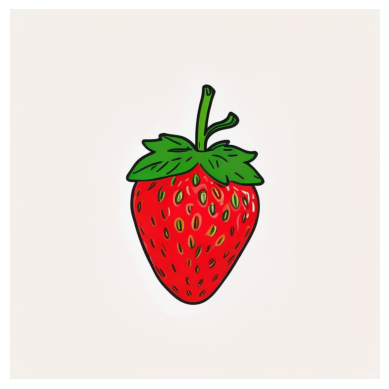

In [12]:
## text to image generator from user's input ##

# desired text prompt
hebrew_prompt  = input(" :בבקשה הכנס/י את התמונה שתרצי/שתרצה בספר")
general_prompt = hebrew_translator(hebrew_prompt)
picture_type  = input(" :בבקשה הכנס/י את הקטגוריה של התמונה (פרי, ירק, מספר, אות)")
picture_type = hebrew_translator(picture_type)

# UPDATED: Prompt strategy for SINGLE OBJECT ONLY (No background/details)
user_prompt_text = (
    f"A Single isolated {general_prompt} centered on a white background, "
    f"classified as {picture_type}."
)

style_prompt = f"""
Simple child's drawing,
2D flat design, outlines only,
single thin black pen,
minimalistic,
continuos singal pen draw,
broad strokes,
white background.
"""

negative_prompt = """
background, scenery, environment, surroundings,
extra items, shading, shadows, gradients, grayscale,
fine lines, intricate details, complex patterns,
realistic texture, hair texture, dots, 3D, depth, perspective,
messy sketchy lines, broken lines.
"""

# Combine prompts into one string to avoid argument collision
final_prompt = user_prompt_text + " " + style_prompt.replace("\n", " ")

# Generate the image
image = pipe(prompt=final_prompt, negative_prompt=negative_prompt, num_inference_steps=25, guidance_scale=8.5).images[0]

# plot results
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [13]:
## Braille converter
hebrew_prompt = add_nikud(hebrew_prompt)
Braille = convert_to_braille(hebrew_prompt)
print(Braille)

האם זו ו עם חולם vo / שורוק vu / רגיל v? (חו/ש/ר) ש
⠹⠥⠹


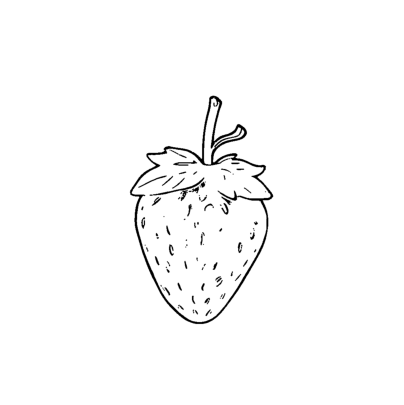

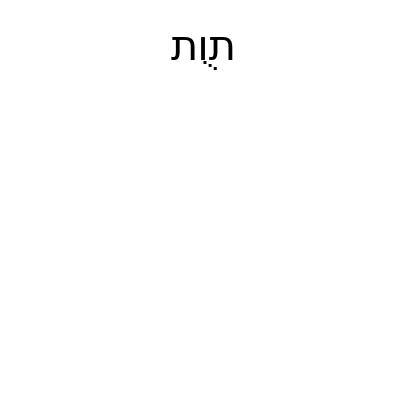

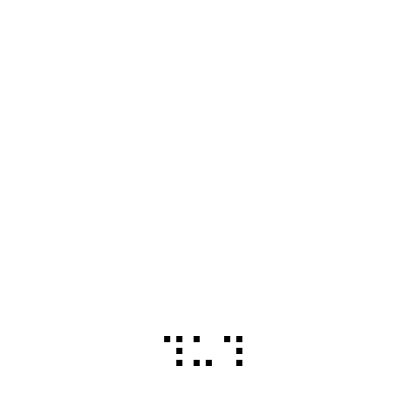

In [49]:
#image processing
image = np.array(image)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray_image, (3, 3), 0)
_, bin_img = cv2.threshold(blurred, 35, 255, cv2.THRESH_BINARY_INV)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
processed = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel)


# Ensure borders are clear (sometimes padding helps)
# (Optional: Add white border if needed, usually SD handles it)

# --- 4. PREPARE FOR CENTERING ---
# The centering logic below expects Lines=Black (0) and BG=White (255)
# So we invert our processed binary image.
edges = cv2.bitwise_not(processed) # Now Lines=0, BG=255

h, w = edges.shape
# Force 1px border to white to prevent boundary artifacts
edges[0:h, 0] = 255
edges[0:h, w-1] = 255
edges[0, 0:w] = 255
edges[h-1, 0:w] = 255

#centering object
h, w = edges.shape
ys, xs = np.where(edges == 0) # Find Black Pixels (The Drawing)

if len(xs) > 0 and len(ys) > 0:
    obj_cx = xs.mean()
    obj_cy = ys.mean()
    img_cx = w / 2
    img_cy = h / 2
    shift_x = int(img_cx - obj_cx)
    shift_y = int(img_cy - obj_cy)
    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    # Use borderValue=255 (White) for padding
    centered = cv2.warpAffine(edges, M, (w, h), borderValue=255)
else:
    # Fallback if image is blank
    centered = edges.copy()

#plotting final result
# --- 1. Image only ---
plt.figure(figsize=(5,5))
plt.imshow(centered, cmap="gray")
plt.axis("off")
plt.savefig("image_only.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()
plt.close()

# --- 2. Hebrew text only ---
plt.figure(figsize=(5,5))
plt.gca().set_facecolor("white")
plt.text(0.5, 0.9, f'{hebrew_prompt[::-1]}',fontsize=30, color='black', ha='center', va='center', fontweight='light',fontname='DejaVu Sans')
plt.axis("off")
plt.savefig("hebrew.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()
plt.close()

# --- 3. Braille text only ---
plt.figure(figsize=(5,5))
plt.gca().set_facecolor("white")
plt.text(0.5, 0.1, f'{Braille}',fontsize=30, color='black', ha='center', va='center', fontweight='light',fontname='Users/barak/book_generator_tom/NotoSansSymbols2-Regular.ttf') # Fixed font path reference just in case
plt.axis("off")
plt.savefig("braille.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()
plt.close()

In [50]:
# Saving as dxf
image_to_dxf_exact(centered, "image_only.dxf")
png_to_dxf("hebrew.png", "hebrew.dxf")
png_to_dxf("braille.png", "braille.dxf")


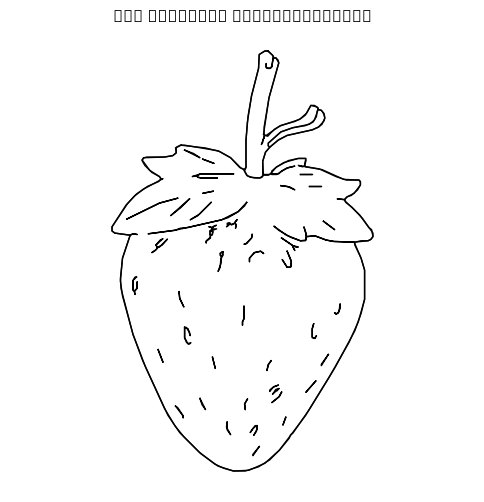

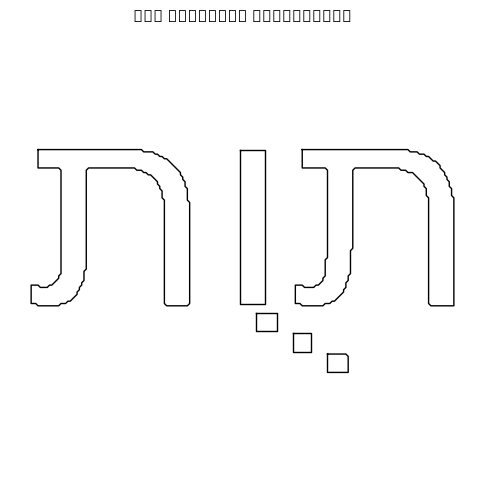

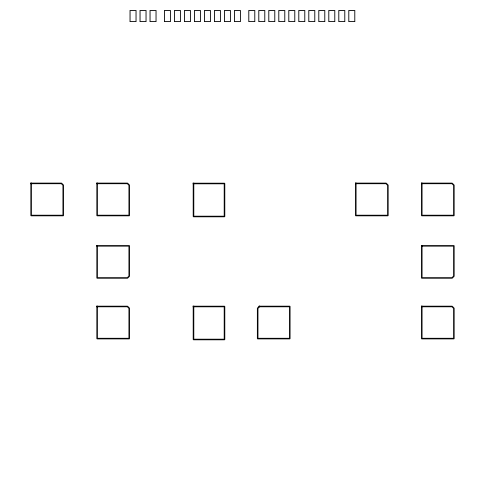

In [51]:
def plot_dxf(dxf_path):
    import ezdxf
    import matplotlib.pyplot as plt
    import numpy as np

    try:
        doc = ezdxf.readfile(dxf_path)
        msp = doc.modelspace()

        plt.figure(figsize=(6, 6))

        for entity in msp:
            if entity.dxftype() == 'LWPOLYLINE':
                points = entity.get_points()
                x = [p[0] for p in points]
                y = [p[1] for p in points]

                if entity.is_closed:
                    x.append(x[0])
                    y.append(y[0])

                plt.plot(x, y, color='black', linewidth=1)

            elif entity.dxftype() == 'CIRCLE':
                center = entity.dxf.center
                radius = entity.dxf.radius

                theta = np.linspace(0, 2*np.pi, 100)
                x = center.x + radius * np.cos(theta)
                y = center.y + radius * np.sin(theta)

                plt.plot(x, y, color='black', linewidth=1)

        plt.axis('equal')
        plt.title(f"DXF Preview: {dxf_path}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Could not plot DXF: {e}")

# Visualize the results
plot_dxf("image_only.dxf")
plot_dxf("hebrew.dxf")
plot_dxf("braille.dxf")